In [1]:
%pip install -q faiss-cpu numpy pandas matplotlib seaborn h5py requests

import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import faiss

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

K = 100
MAX_VECTORS = 1_000_000
N_QUERIES = 10_000
DATA_DIR = Path("data")
LOCAL_FASTTEXT_PATH = DATA_DIR / "crawl-300d-2M.vec"

Note: you may need to restart the kernel to use updated packages.


fastText Common Crawl `crawl-300d-2M` (2M векторов, 300d): https://fasttext.cc/docs/en/english-vectors.html

In [3]:
def load_fasttext_vec(vec_path: Path, max_vectors=None, dtype=np.float32):
    with open(vec_path, "r", encoding="utf-8", errors="ignore") as f:
        header = f.readline().strip().split()
        total_n, d = int(header[0]), int(header[1])

        if max_vectors is None:
            n = total_n
        else:
            n = min(max_vectors, total_n)

        xb = np.empty((n, d), dtype=dtype)

        i = 0
        for line in f:
            if i >= n:
                break
            parts = line.rstrip().split()
            if len(parts) < d + 1:
                continue
            vec = np.asarray(parts[-d:], dtype=dtype)
            xb[i] = vec
            i += 1

    if i < n:
        xb = xb[:i]

    return xb, {"source": "fasttext", "total_vectors_header": total_n, "loaded_vectors": xb.shape[0], "dim": xb.shape[1]}


dataset_name = "fasttext-crawl-300d-2M"
xb, ds_meta = load_fasttext_vec(LOCAL_FASTTEXT_PATH, max_vectors=MAX_VECTORS)
ds_meta

{'source': 'fasttext',
 'total_vectors_header': 2000000,
 'loaded_vectors': 1000000,
 'dim': 300}

In [4]:
xb = np.asarray(xb, dtype=np.float32, order="C")
assert xb.ndim == 2
n, d = xb.shape

faiss.normalize_L2(xb)

print(f"n={n:,}, d={d}")

n=1,000,000, d=300


In [5]:
query_ids = np.random.choice(n, size=N_QUERIES, replace=False)
query_ids.sort()

xq = xb[query_ids].copy()

print("queries:", xq.shape)
print("unique query ids:", len(np.unique(query_ids)))

queries: (10000, 300)
unique query ids: 10000


kNN gt (Top-100)

In [6]:
index_gt = faiss.IndexFlatIP(d)
index_gt.add(xb)
_, gt_I = index_gt.search(xq, K)
gt_I.shape

(10000, 100)

In [13]:
def recall_at_k(gt_idx: np.ndarray, pred_idx: np.ndarray, k: int = 100) -> float:
    gt_top = gt_idx[:, :k]
    pr_top = pred_idx[:, :k]
    hits = 0
    for i in range(gt_top.shape[0]):
        hits += len(set(gt_top[i].tolist()) & set(pr_top[i].tolist()))
    return hits / (gt_top.shape[0] * k)


def index_size_bytes(index) -> int:
    return len(faiss.serialize_index(index))


def run_benchmark(index_name, params, xb, xq, gt_I, k=100, batch_size=512, train_data=None):
    d = xb.shape[1]
    metric = faiss.METRIC_INNER_PRODUCT

    t0 = time.perf_counter()

    if index_name == "LSH":
        nbits = params["nbits"]
        index = faiss.IndexLSH(d, nbits)

    elif index_name == "HNSW":
        M = params["M"]
        efc = params["efConstruction"]
        index = faiss.IndexHNSWFlat(d, M, metric)
        index.hnsw.efConstruction = efc

    elif index_name == "IVFPQ":
        nlist = params["nlist"]
        m = params["m"]
        nbits = params["nbits"]

        quantizer = faiss.IndexFlatIP(d)
        index = faiss.IndexIVFPQ(quantizer, d, nlist, m, nbits, metric)

        tr = train_data if train_data is not None else xb
        index.train(tr)
    else:
        raise ValueError(f"Unknown index_name={index_name}")

    index.add(xb)
    build_time = time.perf_counter() - t0

    if index_name == "HNSW":
        index.hnsw.efSearch = params["efSearch"]
    if index_name == "IVFPQ":
        index.nprobe = params["nprobe"]

    t1 = time.perf_counter()
    all_I = []
    for i in range(0, xq.shape[0], batch_size):
        q = xq[i : i + batch_size]
        _, I = index.search(q, k)
        all_I.append(I)
    pred_I = np.vstack(all_I)
    search_time = time.perf_counter() - t1

    rec = recall_at_k(gt_I, pred_I, k)
    size_b = index_size_bytes(index)

    return {
        "index": index_name,
        "params": json.dumps(params, ensure_ascii=False),
        "recall": rec,
        "build_time_sec": build_time,
        "search_time_sec_total": search_time,
        "avg_query_ms": (search_time / xq.shape[0]) * 1000,
        "index_size_mb": size_b / (1024 * 1024),
    }


results = []

### LSH (Faiss IndexLSH)

In [17]:
lsh_grid = [
    {"nbits": 256},
    {"nbits": 512},
    {"nbits": 1024},
    {"nbits": 2048},
    {"nbits": 4096},
    {"nbits": 8096},
]

for p in lsh_grid:
    print("LSH:", p)
    res = run_benchmark("LSH", p, xb, xq, gt_I, k=K)
    results.append(res)

lsh_df = pd.DataFrame([r for r in results if r["index"] == "LSH"])
lsh_df.sort_values(["recall", "avg_query_ms"], ascending=[False, True])

LSH: {'nbits': 256}
LSH: {'nbits': 512}
LSH: {'nbits': 1024}
LSH: {'nbits': 2048}
LSH: {'nbits': 4096}
LSH: {'nbits': 8096}


,index,params,recall,build_time_sec,search_time_sec_total,avg_query_ms,index_size_mb
5,LSH,"{""nbits"": 8096}",0.869221,262.580723,63.516644,6.351664,974.383634
4,LSH,"{""nbits"": 4096}",0.818044,27.711266,25.443697,2.544370,492.968839
3,LSH,"{""nbits"": 2048}",0.748478,3.159212,11.239130,1.123913,246.484464
2,LSH,"{""nbits"": 1024}",0.654716,2.288007,6.611348,0.661135,123.242276
1,LSH,"{""nbits"": 512}",0.539162,0.547662,3.687460,0.368746,61.621182
0,LSH,"{""nbits"": 256}",0.391094,0.241706,2.982440,0.298244,30.810636


### HNSW (Faiss IndexHNSWFlat)

In [18]:
hnsw_grid = []
for M in [32, 64]:
    for efc in [128, 256]:
        for efs in [128, 256]:
            hnsw_grid.append({"M": M, "efConstruction": efc, "efSearch": efs})

for p in hnsw_grid:
    print("HNSW:", p)
    res = run_benchmark("HNSW", p, xb, xq, gt_I, k=K)
    results.append(res)

hnsw_df = pd.DataFrame([r for r in results if r["index"] == "HNSW"])
hnsw_df.sort_values(["recall", "avg_query_ms"], ascending=[False, True]).head(10)

HNSW: {'M': 32, 'efConstruction': 128, 'efSearch': 128}
HNSW: {'M': 32, 'efConstruction': 128, 'efSearch': 256}
HNSW: {'M': 32, 'efConstruction': 256, 'efSearch': 128}
HNSW: {'M': 32, 'efConstruction': 256, 'efSearch': 256}
HNSW: {'M': 64, 'efConstruction': 128, 'efSearch': 128}
HNSW: {'M': 64, 'efConstruction': 128, 'efSearch': 256}
HNSW: {'M': 64, 'efConstruction': 256, 'efSearch': 128}
HNSW: {'M': 64, 'efConstruction': 256, 'efSearch': 256}


,index,params,recall,build_time_sec,search_time_sec_total,avg_query_ms,index_size_mb
7,HNSW,"{""M"": 64, ""efConstruction"": 256, ""efSearch"": 256}",0.990031,242.107843,2.198016,0.219802,1648.008749
3,HNSW,"{""M"": 32, ""efConstruction"": 256, ""efSearch"": 256}",0.987313,198.989214,1.865691,0.186569,1403.932100
5,HNSW,"{""M"": 64, ""efConstruction"": 128, ""efSearch"": 256}",0.980693,110.869461,1.887711,0.188771,1648.008749
6,HNSW,"{""M"": 64, ""efConstruction"": 256, ""efSearch"": 128}",0.979086,249.750359,1.361854,0.136185,1648.008749
1,HNSW,"{""M"": 32, ""efConstruction"": 128, ""efSearch"": 256}",0.978156,91.135466,1.516322,0.151632,1403.932100
2,HNSW,"{""M"": 32, ""efConstruction"": 256, ""efSearch"": 128}",0.972521,198.735927,1.048560,0.104856,1403.932100
4,HNSW,"{""M"": 64, ""efConstruction"": 128, ""efSearch"": 128}",0.963101,109.644618,1.062185,0.106218,1648.008749
0,HNSW,"{""M"": 32, ""efConstruction"": 128, ""efSearch"": 128}",0.957632,97.131013,0.855893,0.085589,1403.932100


### IVF+PQ (Faiss IndexIVFPQ)

In [16]:
n_train = 200_000
n_train = min(n_train, xb.shape[0])
train_ids = np.random.choice(xb.shape[0], size=n_train, replace=False)
xt = xb[train_ids].copy()

ivfpq_grid = []
for nlist in [4096]:
    for nprobe in [128, 256, 512]:
        for m in [50, 100, 150]:
            if d % m == 0:
                ivfpq_grid.append(
                    {
                        "nlist": nlist,
                        "nprobe": nprobe,
                        "m": m,
                        "nbits": 8,
                    }
                )

for p in ivfpq_grid:
    print("IVFPQ:", p)
    res = run_benchmark("IVFPQ", p, xb, xq, gt_I, k=K, train_data=xt)
    results.append(res)

ivfpq_df = pd.DataFrame([r for r in results if r["index"] == "IVFPQ"])
display(ivfpq_df.sort_values(["recall", "avg_query_ms"], ascending=[False, True]).head(10))

IVFPQ: {'nlist': 4096, 'nprobe': 128, 'm': 50, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 128, 'm': 100, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 128, 'm': 150, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 256, 'm': 50, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 256, 'm': 100, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 256, 'm': 150, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 512, 'm': 50, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 512, 'm': 100, 'nbits': 8}
IVFPQ: {'nlist': 4096, 'nprobe': 512, 'm': 150, 'nbits': 8}


,index,params,recall,build_time_sec,search_time_sec_total,avg_query_ms,index_size_mb
18,IVFPQ,"{""nlist"": 4096, ""nprobe"": 512, ""m"": 150, ""nbit...",0.939028,26.026363,11.413728,1.141373,155.692432
15,IVFPQ,"{""nlist"": 4096, ""nprobe"": 256, ""m"": 150, ""nbit...",0.932479,25.741454,6.345992,0.634599,155.692432
12,IVFPQ,"{""nlist"": 4096, ""nprobe"": 128, ""m"": 150, ""nbit...",0.920626,26.428035,3.130427,0.313043,155.692432
17,IVFPQ,"{""nlist"": 4096, ""nprobe"": 512, ""m"": 100, ""nbit...",0.871279,22.075813,5.625019,0.562502,108.008717
9,IVFPQ,"{""nlist"": 4096, ""nprobe"": 256, ""m"": 100, ""nbit...",0.866479,22.147855,2.967635,0.296764,108.008717
14,IVFPQ,"{""nlist"": 4096, ""nprobe"": 256, ""m"": 100, ""nbit...",0.866454,22.059754,2.902616,0.290262,108.008717
11,IVFPQ,"{""nlist"": 4096, ""nprobe"": 128, ""m"": 100, ""nbit...",0.857971,22.725371,1.700037,0.170004,108.008717
6,IVFPQ,"{""nlist"": 4096, ""nprobe"": 128, ""m"": 100, ""nbit...",0.857537,22.302969,1.691398,0.169140,108.008717
16,IVFPQ,"{""nlist"": 4096, ""nprobe"": 512, ""m"": 50, ""nbits...",0.694022,18.605882,3.071007,0.307101,60.325001
13,IVFPQ,"{""nlist"": 4096, ""nprobe"": 256, ""m"": 50, ""nbits...",0.692555,17.790274,1.394442,0.139444,60.325001


In [19]:
all_df = pd.DataFrame(results).sort_values(["index", "recall", "avg_query_ms"], ascending=[True, False, True])

best_per_index = (
    all_df.sort_values(["index", "recall", "avg_query_ms"], ascending=[True, False, True])
    .groupby("index", as_index=False)
    .first()
)

display(all_df.head())
display(best_per_index)

,index,params,recall,build_time_sec,search_time_sec_total,avg_query_ms,index_size_mb
32,HNSW,"{""M"": 64, ""efConstruction"": 256, ""efSearch"": 256}",0.990031,242.107843,2.198016,0.219802,1648.008749
28,HNSW,"{""M"": 32, ""efConstruction"": 256, ""efSearch"": 256}",0.987313,198.989214,1.865691,0.186569,1403.932100
30,HNSW,"{""M"": 64, ""efConstruction"": 128, ""efSearch"": 256}",0.980693,110.869461,1.887711,0.188771,1648.008749
31,HNSW,"{""M"": 64, ""efConstruction"": 256, ""efSearch"": 128}",0.979086,249.750359,1.361854,0.136185,1648.008749
26,HNSW,"{""M"": 32, ""efConstruction"": 128, ""efSearch"": 256}",0.978156,91.135466,1.516322,0.151632,1403.932100


,index,params,recall,build_time_sec,search_time_sec_total,avg_query_ms,index_size_mb
0,HNSW,"{""M"": 64, ""efConstruction"": 256, ""efSearch"": 256}",0.990031,242.107843,2.198016,0.219802,1648.008749
1,IVFPQ,"{""nlist"": 4096, ""nprobe"": 512, ""m"": 150, ""nbit...",0.939028,26.026363,11.413728,1.141373,155.692432
2,LSH,"{""nbits"": 8096}",0.869221,262.580723,63.516644,6.351664,974.383634


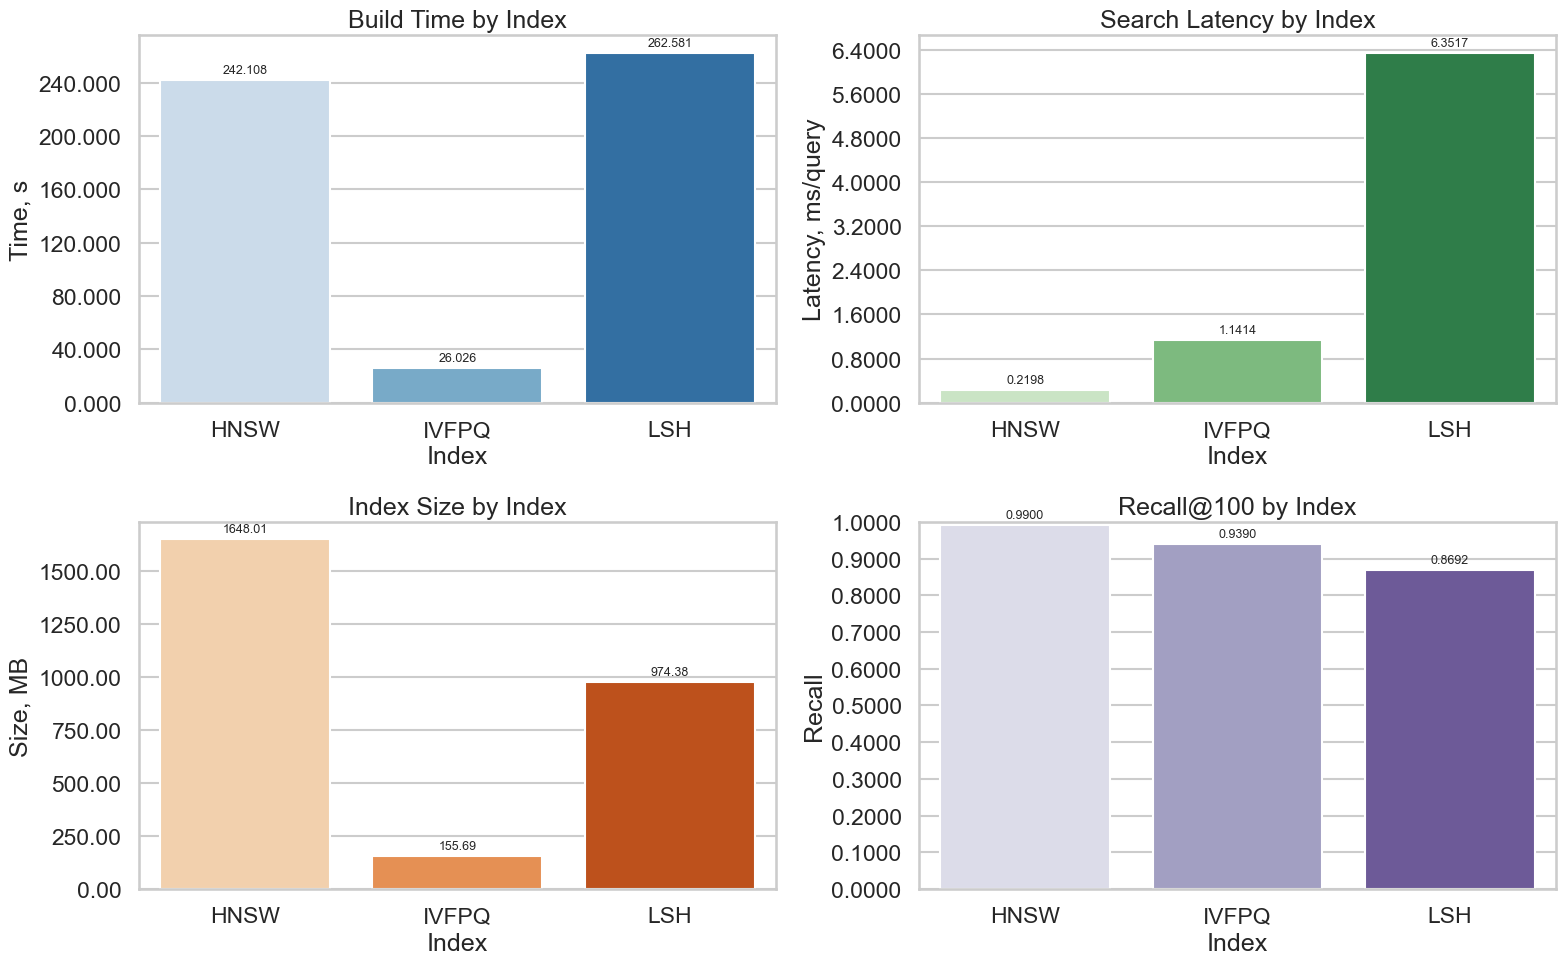

In [22]:
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

plot_df = best_per_index.copy().sort_values("index").reset_index(drop=True)
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=plot_df, x="index", y="build_time_sec", hue="index", legend=False, ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Build Time by Index")
axes[0, 0].set_xlabel("Index")
axes[0, 0].set_ylabel("Time, s")
axes[0, 0].yaxis.set_major_locator(MaxNLocator(nbins=8))
axes[0, 0].yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

sns.barplot(data=plot_df, x="index", y="avg_query_ms", hue="index", legend=False, ax=axes[0, 1], palette="Greens")
axes[0, 1].set_title("Search Latency by Index")
axes[0, 1].set_xlabel("Index")
axes[0, 1].set_ylabel("Latency, ms/query")
axes[0, 1].yaxis.set_major_locator(MaxNLocator(nbins=10))
axes[0, 1].yaxis.set_major_formatter(FormatStrFormatter("%.4f"))

sns.barplot(data=plot_df, x="index", y="index_size_mb", hue="index", legend=False, ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Index Size by Index")
axes[1, 0].set_xlabel("Index")
axes[1, 0].set_ylabel("Size, MB")
axes[1, 0].yaxis.set_major_locator(MaxNLocator(nbins=8))
axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

sns.barplot(data=plot_df, x="index", y="recall", hue="index", legend=False, ax=axes[1, 1], palette="Purples")
axes[1, 1].set_title("Recall@100 by Index")
axes[1, 1].set_xlabel("Index")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].set_ylim(0, min(1.0, plot_df["recall"].max() * 1.08))
axes[1, 1].yaxis.set_major_locator(MaxNLocator(nbins=10))
axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter("%.4f"))

for ax, fmt in [
    (axes[0, 0], "{:.3f}"),
    (axes[0, 1], "{:.4f}"),
    (axes[1, 0], "{:.2f}"),
    (axes[1, 1], "{:.4f}"),
]:
    for c in ax.containers:
        labels = [fmt.format(v.get_height()) for v in c]
        ax.bar_label(c, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()